In [1]:
import os

os.environ["KERAS_BACKEND"] = "tensorflow"
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' # Only errors are logged
os.environ['TF_GPU_ALLOCATOR'] ='cuda_malloc_async'

import numpy as np
import keras
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import layers
from keras import ops

# TF imports related to tf.data preprocessing
from tensorflow import data as tf_data
from tensorflow import image as tf_image
from tensorflow.keras.utils import plot_model

keras.utils.set_random_seed(42)


I0000 00:00:1776983570.648628  139806 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776983571.708033  139806 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
BATCH_SIZE = 64
NUM_CLASSES = 8
EPOCHS = 50
SAMPLE_RATE = 16000
OUT_SEQ_LEN = 72000

In [3]:
keras.backend.clear_session(free_memory=True)
train_ds =tf.keras.utils.image_dataset_from_directory(directory='dataset_mel_img/train',
image_size=(300, 300),
batch_size=BATCH_SIZE)
val_ds =tf.keras.utils.image_dataset_from_directory(directory='dataset_mel_img/val',
image_size=(300, 300),
batch_size=BATCH_SIZE)
test_ds =tf.keras.utils.image_dataset_from_directory(directory='dataset_mel_img/test',
image_size=(300, 300),
batch_size=BATCH_SIZE)

Found 14840 files belonging to 8 classes.
Found 636 files belonging to 8 classes.
Found 636 files belonging to 8 classes.


In [ ]:
incv3 = keras.applications.InceptionV3(include_top=False,input_shape=(300,300,3),pooling='max')
incv3.trainable = False
model = keras.Sequential([
  layers.Input(shape=(300,300,3),name='input'),
  # layers.Resizing(299,299),
#   tf.keras.layers.Lambda(tf.image.grayscale_to_rgb),
  incv3,
  # layers.Dropout(0.4),
  # layers.GlobalAveragePooling2D(name='gp'),
  layers.Dense((1024),activation='relu'),
  layers.Dense((512),activation='relu'),
  # layers.Dropout(0.5),
  layers.Dense((NUM_CLASSES),activation = 'softmax',name='output')
])

In [5]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 2048)           │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 8)              │         4,104 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,429,864 (93.19 MB)

 Trainable params: 24,395,432 (93.06 MB)

 Non-trainable params: 34,432 (134.50 KB)

In [6]:
keras.backend.clear_session(free_memory=True)
model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=1e-4),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[keras.metrics.SparseCategoricalAccuracy()],
)


In [7]:
keras.backend.clear_session(free_memory=True)
history = model.fit(train_ds,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        validation_data=val_ds,
        callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=EPOCHS/10,
            restore_best_weights=True,
        )]
        )

Epoch 1/50
232/232 ━━━━━━━━━━━━━━━━━━━━ 200s 562ms/step - loss: 1.9914 - sparse_categorical_accuracy: 0.2553 - val_loss: 2.3541 - val_sparse_categorical_accuracy: 0.1305
Epoch 2/50
232/232 ━━━━━━━━━━━━━━━━━━━━ 64s 275ms/step - loss: 1.6315 - sparse_categorical_accuracy: 0.3232 - val_loss: 1.7242 - val_sparse_categorical_accuracy: 0.3050
Epoch 3/50
232/232 ━━━━━━━━━━━━━━━━━━━━ 64s 275ms/step - loss: 1.4978 - sparse_categorical_accuracy: 0.3704 - val_loss: 1.3912 - val_sparse_categorical_accuracy: 0.4214
Epoch 4/50
232/232 ━━━━━━━━━━━━━━━━━━━━ 64s 275ms/step - loss: 1.3666 - sparse_categorical_accuracy: 0.4259 - val_loss: 1.2341 - val_sparse_categorical_accuracy: 0.4906
Epoch 5/50
232/232 ━━━━━━━━━━━━━━━━━━━━ 44s 189ms/step - loss: 1.2116 - sparse_categorical_accuracy: 0.5131 - val_loss: 1.1934 - val_sparse_categorical_accuracy: 0.5456
Epoch 6/50
232/232 ━━━━━━━━━━━━━━━━━━━━ 31s 135ms/step - loss: 1.0632 - sparse_categorical_accuracy: 0.5806 - val_loss: 1.5978 - val_sparse_categorical_ac

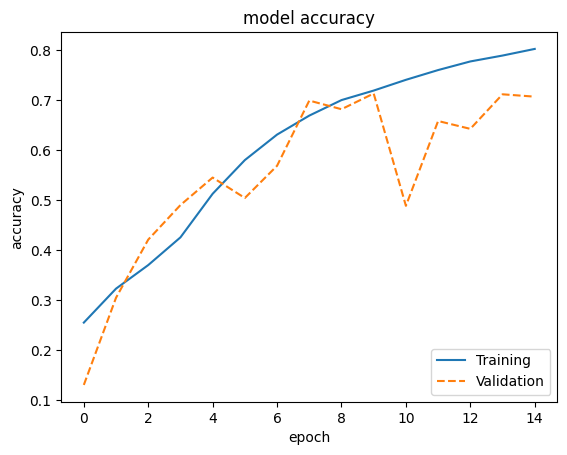

In [8]:
plt.plot(history.history['sparse_categorical_accuracy'])
plt.plot(history.history['val_sparse_categorical_accuracy'],linestyle='--')
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Training', 'Validation'], loc='lower right')
plt.show()

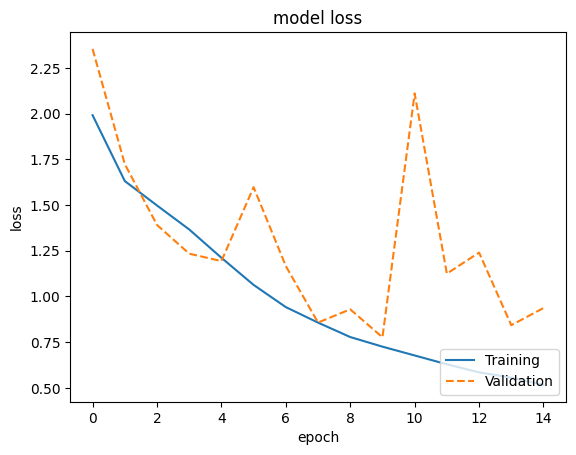

In [9]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'],linestyle='--')
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['Training', 'Validation'], loc='lower right')
plt.show()

In [10]:
model.evaluate(test_ds)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.8155 - sparse_categorical_accuracy: 0.6981


[0.815468430519104, 0.698113203048706]